14:29:09 - cmdstanpy - INFO - Chain [1] start processing
14:29:09 - cmdstanpy - INFO - Chain [1] done processing
14:29:09 - cmdstanpy - INFO - Chain [1] start processing



=== En iyi Öğrenici Parametreleri (VAL'a göre) ===
RF : {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}  | VAL_MAE=56.94
XGB: {'n_estimators': 700, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_lambda': 2.0, 'random_state': 42}  | VAL_MAE=47.10


14:29:09 - cmdstanpy - INFO - Chain [1] done processing
14:29:09 - cmdstanpy - INFO - Chain [1] start processing
14:29:09 - cmdstanpy - INFO - Chain [1] done processing
14:29:17 - cmdstanpy - INFO - Chain [1] start processing
14:29:18 - cmdstanpy - INFO - Chain [1] done processing
14:29:25 - cmdstanpy - INFO - Chain [1] start processing
14:29:25 - cmdstanpy - INFO - Chain [1] done processing
14:29:33 - cmdstanpy - INFO - Chain [1] start processing
14:29:33 - cmdstanpy - INFO - Chain [1] done processing
14:29:42 - cmdstanpy - INFO - Chain [1] start processing
14:29:42 - cmdstanpy - INFO - Chain [1] done processing
14:29:49 - cmdstanpy - INFO - Chain [1] start processing
14:29:49 - cmdstanpy - INFO - Chain [1] done processing
14:29:57 - cmdstanpy - INFO - Chain [1] start processing
14:29:57 - cmdstanpy - INFO - Chain [1] done processing
14:29:57 - cmdstanpy - INFO - Chain [1] start processing
14:29:57 - cmdstanpy - INFO - Chain [1] done processing
14:29:57 - cmdstanpy - INFO - Chain [1] 


=== Sonuç Özeti — Original vs Patched ===
   Block                          Strategy           Model   MAE   RMSE  MAPE
Original   Inverse-MAE weighted (original)  RF (recursive) 63.29  81.78 60.32
Original   Inverse-MAE weighted (original) XGB (recursive) 85.51 114.67 78.93
Original                      Prophet-only  RF (recursive) 61.58  72.62 55.07
Original                      Prophet-only XGB (recursive) 77.31 107.69 74.33
Original          Weighted fixed (favor P)  RF (recursive) 58.93  76.59 56.45
Original          Weighted fixed (favor P) XGB (recursive) 86.60 114.94 79.44
 Patched    Inverse-MAE weighted (patched)  RF (recursive) 59.92  77.51 57.25
 Patched    Inverse-MAE weighted (patched) XGB (recursive) 90.67 117.19 82.40
 Patched            Prophet-only (patched)  RF (recursive) 64.19  78.27 58.53
 Patched            Prophet-only (patched) XGB (recursive) 82.31 110.13 77.52
 Patched Weighted fixed (favor P, patched)  RF (recursive) 59.28  76.73 56.67
 Patched Weighted fix

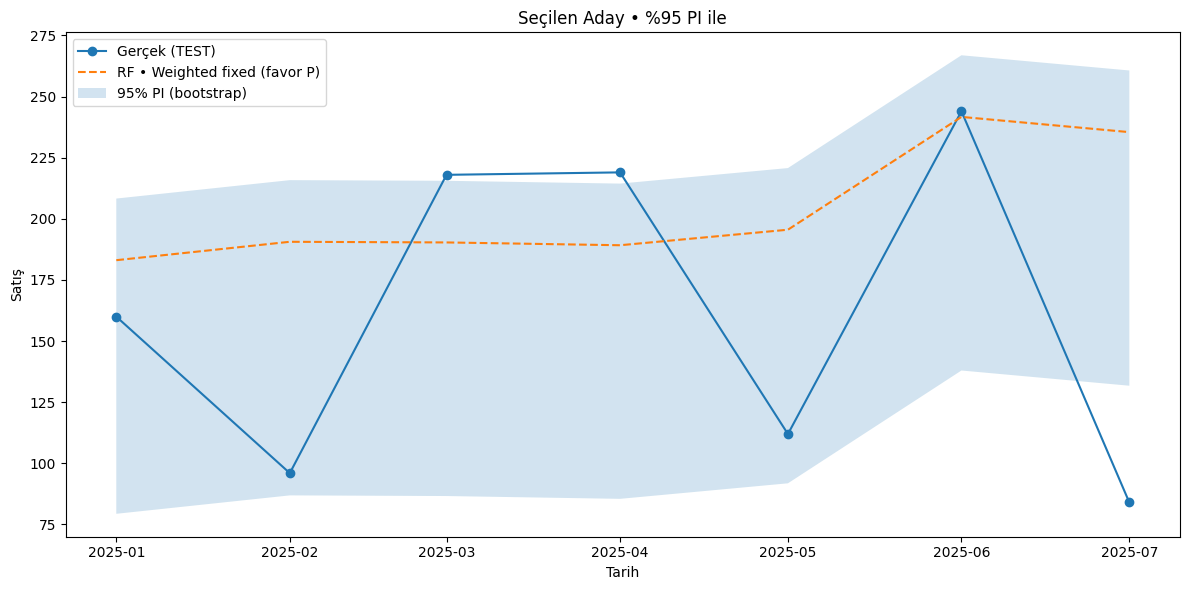


[Özet] İlk 10 aday (bootstrap ortalama MAE artan):
   Block                          Strategy Model  boot_mean_MAE  boot_lo_MAE  boot_hi_MAE  boot_mean_SCORE  boot_lo_SCORE  boot_hi_SCORE
Original          Weighted fixed (favor P)    RF          58.05        25.25        97.48            62.00          26.21         103.07
 Patched Weighted fixed (favor P, patched)    RF          58.40        25.60        97.43            62.29          27.07         102.30
 Patched    Inverse-MAE weighted (patched)    RF          59.02        25.81        98.48            62.93          27.64         103.42
Original                      Prophet-only    RF          60.90        35.67        91.58            62.31          33.43          95.55
Original   Inverse-MAE weighted (original)    RF          62.31        27.42       103.34            66.45          30.02         107.92
 Patched            Prophet-only (patched)    RF          63.38        35.21        99.71            65.62          33.63     

In [4]:
# ==============================================================
# Betik B (Patched): Exog Ensemble Tuning + Sızıntısız/Kausal + PI
#  - Original Betik B exog stratejileri ile Patched sürümü kıyaslar
#  - RF & XGB (HP araması VAL üzerinde)
#  - %95 güven aralığı (residual bootstrap, kausal)
# ==============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

VAL_START  = pd.Timestamp("2024-07-01")
VAL_END    = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")

RANDOM_STATE = 42
EXOG_VAL_H   = 6     # exog yöntemlerinin geriye dönük validation ufku (ay)
EPS_PROPHET  = 0.05  # inverse-MAE'de Prophet'e küçük taban ağırlık
BOOT_N       = 1000  # PI bootstrap sayısı

FEATURES = [
    "orders","stock",
    "orders_lag1","orders_lag3",
    "stock_lag1","stock_lag3",
    "y_lag1",
    "orders_ratio",
    "month","year",
]

# ------------------ Metrics & Utils ------------------
def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(((y_pred - y_true)**2).mean())
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

def ensure_ms_freq(df):
    d = df.copy().sort_values("ds")
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    d = d.set_index("ds").sort_index()
    d.index = pd.DatetimeIndex(d.index, freq="MS")
    return d.reset_index()

def add_calendar(df):
    d = df.copy()
    d["year"]  = d["ds"].dt.year
    d["month"] = d["ds"].dt.month
    return d

def rolling_impute(s, causal=False):
    x = pd.to_numeric(s, errors="coerce")
    if causal:
        x = x.ffill()
        x = x.rolling(window=3, min_periods=1).mean()
        x = x.bfill()
    else:
        roll = x.rolling(window=3, center=True, min_periods=1).mean()
        x = x.where(~x.isna(), roll).ffill().bfill()
    return x

def smooth_causal_ma(s, window=3):
    x = pd.to_numeric(s, errors="coerce").ffill()
    return x.rolling(window=window, min_periods=1).mean().bfill()

def winsorize_series(s, lower_q=0.05, upper_q=0.95):
    x = pd.to_numeric(s, errors="coerce")
    lo = np.nanpercentile(x, lower_q*100)
    hi = np.nanpercentile(x, upper_q*100)
    return x.clip(lo, hi)

def nonneg(s):
    return pd.to_numeric(s, errors="coerce").clip(lower=0.0)

def build_lags_minimal(df):
    d = df.copy()
    if "orders" in d.columns and "stock" in d.columns:
        d["orders_ratio"] = d["orders"] / d["stock"].replace(0, np.nan)
    if "y" in d.columns:
        d["y_lag1"] = d["y"].shift(1)
    if "orders" in d.columns:
        d["orders_lag1"] = d["orders"].shift(1)
        d["orders_lag3"] = d["orders"].shift(3)
    if "stock" in d.columns:
        d["stock_lag1"] = d["stock"].shift(1)
        d["stock_lag3"] = d["stock"].shift(3)
    return d

def prep_features(df_in, causal=False):
    d = add_calendar(df_in)
    d = build_lags_minimal(d)
    for col in ["orders","stock"]:
        if col in d.columns:
            d[col] = rolling_impute(d[col], causal=causal)
    for col in ["orders_lag1","orders_lag3","stock_lag1","stock_lag3","y_lag1","orders_ratio"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce").ffill().bfill().fillna(0.0)
    for c in FEATURES:
        if c not in d.columns:
            d[c] = 0.0
    return d.replace([np.inf, -np.inf], np.nan).fillna(0)

# ------------------ Univariate fit/predict (fit < TEST_START) ------------------
def fit_prophet(train_df, value_col):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    m.fit(train_df.rename(columns={value_col:"y"}))
    return m

def forecast_prophet(model, steps):
    fut = model.make_future_dataframe(periods=steps, freq="MS")
    fc  = model.predict(fut)[["ds","yhat"]].tail(steps)
    return fc.rename(columns={"yhat":"yhat"})

def sarima_fit_best(y, p_range=(0,3), q_range=(0,3), P_range=(0,1), Q_range=(0,1)):
    best, best_aic = None, np.inf
    for p in range(p_range[0], p_range[1]+1):
        for q in range(q_range[0], q_range[1]+1):
            for P in range(P_range[0], P_range[1]+1):
                for Q in range(Q_range[0], Q_range[1]+1):
                    try:
                        r = SARIMAX(y, order=(p,1,q), seasonal_order=(P,1,Q,12),
                                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                        if r.aic < best_aic:
                            best_aic = r.aic
                            best = ((p,1,q),(P,1,Q,12))
                    except Exception:
                        pass
    return best

def fit_sarima(train_df, value_col):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    best = sarima_fit_best(y)
    if best is None:
        return None
    return SARIMAX(y, order=best[0], seasonal_order=best[1],
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def forecast_sarima(model, steps, future_idx):
    pred = model.get_forecast(steps=steps).predicted_mean
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

def fit_ets(train_df, value_col):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    # mini-grid: trend × seasonal × damped
    best, best_aic, best_model = None, np.inf, None
    for trend in ["add", "mul", None]:
        for seasonal in ["add", "mul", None]:
            try:
                for damped in [True, False]:
                    if seasonal is None:
                        model = ExponentialSmoothing(y, trend=trend, seasonal=None, damped_trend=damped).fit(optimized=True)
                    else:
                        model = ExponentialSmoothing(y, trend=trend, seasonal=seasonal, seasonal_periods=12,
                                                     damped_trend=damped).fit(optimized=True)
                    aic = getattr(model, "aic", np.inf)
                    if aic < best_aic:
                        best_aic, best, best_model = aic, (trend, seasonal, damped), model
            except Exception:
                continue
    if best_model is None:
        # fallback
        best_model = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=12).fit(optimized=True)
    return best_model

def forecast_ets(model, steps, future_idx):
    pred = model.forecast(steps)
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

def backtest_mae(series_df, value_col, method, val_h=EXOG_VAL_H):
    s_full = series_df[["ds", value_col]].dropna().sort_values("ds")
    s = s_full[s_full["ds"] < TEST_START]
    if len(s) < val_h + 6:
        return np.inf
    cut = s["ds"].max() - pd.DateOffset(months=val_h-1)
    train = s[s["ds"] < cut]
    val   = s[s["ds"] >= cut]
    steps = len(val)
    try:
        if method == "prophet":
            m = fit_prophet(train, value_col)
            yhat = forecast_prophet(m, steps)["yhat"].values
        elif method == "sarima":
            m = fit_sarima(train, value_col)
            if m is None:
                return np.inf
            yhat = forecast_sarima(m, steps, val["ds"].values)["yhat"].values
        else:
            m = fit_ets(train, value_col)
            yhat = forecast_ets(m, steps, val["ds"].values)["yhat"].values
    except Exception:
        return np.inf
    return mae_rmse_mape(val[value_col].values, yhat)[0]

# ------------------ ORIGINAL exog builders (kıyas için) ------------------
def build_exog_prophet_only_ORIG(df_all, future_idx):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        s = df_all[["ds", col]].dropna().sort_values("ds")
        s = s[s["ds"] < TEST_START]
        if s.empty:
            out[col] = 0.0; continue
        steps = len(future_idx)
        try:
            m  = fit_prophet(s, col)
            fc = forecast_prophet(m, steps).rename(columns={"yhat":col})[["ds",col]]
        except Exception:
            last = s[col].iloc[-1]
            fc = pd.DataFrame({"ds": future_idx, col: last})
        # Original: hafif temizlik
        fc[col] = rolling_impute(fc[col], causal=True)
        out = out.merge(fc, on="ds", how="left")
    for c in ["orders","stock"]:
        out[c] = rolling_impute(out[c], causal=True)
    return out

def build_exog_weighted_fixed_ORIG(df_all, future_idx, w_p=0.60, w_s=0.25, w_e=0.15):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        s = df_all[["ds", col]].dropna().sort_values("ds")
        s = s[s["ds"] < TEST_START]
        if s.empty:
            out[col] = 0.0; continue
        steps = len(future_idx)
        # Prophet
        try:
            mp  = fit_prophet(s, col)
            fcp = forecast_prophet(mp, steps).rename(columns={"yhat":"p"})
        except Exception:
            fcp = pd.DataFrame({"ds": future_idx, "p": np.nan})
        # SARIMA
        try:
            ms  = fit_sarima(s, col)
            if ms is None: raise RuntimeError
            fcs = forecast_sarima(ms, steps, future_idx).rename(columns={"yhat":"s"})
        except Exception:
            fcs = pd.DataFrame({"ds": future_idx, "s": np.nan})
        # ETS
        try:
            me  = fit_ets(s, col)
            fce = forecast_ets(me, steps, future_idx).rename(columns={"yhat":"e"})
        except Exception:
            fce = pd.DataFrame({"ds": future_idx, "e": np.nan})

        tmp = pd.DataFrame({"ds": future_idx}).merge(fcp, on="ds", how="left").merge(fcs, on="ds", how="left").merge(fce, on="ds", how="left")
        tmp[col] = (w_p*tmp["p"] + w_s*tmp["s"] + w_e*tmp["e"])
        tmp[col] = rolling_impute(tmp[col], causal=True)
        out = out.merge(tmp[["ds",col]], on="ds", how="left")
    for c in ["orders","stock"]:
        out[c] = rolling_impute(out[c], causal=True)
    return out

def build_exog_inverse_mae_ORIG(df_all, future_idx, val_h=EXOG_VAL_H):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        s = df_all[["ds", col]].dropna().sort_values("ds")
        s = s[s["ds"] < TEST_START]
        if s.empty:
            out[col] = 0.0; continue
        steps = len(future_idx)
        mae_p = backtest_mae(s, col, "prophet", val_h)
        mae_s = backtest_mae(s, col, "sarima",  val_h)
        mae_e = backtest_mae(s, col, "ets",     val_h)

        # Forecasts
        try:
            mp  = fit_prophet(s, col)
            fcp = forecast_prophet(mp, steps).rename(columns={"yhat":"p"})
        except Exception:
            fcp = pd.DataFrame({"ds": future_idx, "p": np.nan})
        try:
            ms  = fit_sarima(s, col)
            if ms is None: raise RuntimeError
            fcs = forecast_sarima(ms, steps, future_idx).rename(columns={"yhat":"s"})
        except Exception:
            fcs = pd.DataFrame({"ds": future_idx, "s": np.nan})
        try:
            me  = fit_ets(s, col)
            fce = forecast_ets(me, steps, future_idx).rename(columns={"yhat":"e"})
        except Exception:
            fce = pd.DataFrame({"ds": future_idx, "e": np.nan})

        maes = np.array([mae_p, mae_s, mae_e], dtype=float)
        maes = np.where(~np.isfinite(maes) | (maes <= 0), np.nan, maes)
        inv  = 1.0 / maes
        if np.isnan(inv).all():
            wp, ws, we = 0.60, 0.25, 0.15
        else:
            inv = np.where(np.isnan(inv), 0.0, inv)
            ssum = inv.sum()
            if ssum <= 0:
                wp, ws, we = 0.60, 0.25, 0.15
            else:
                wp, ws, we = (inv / ssum)

        tmp = pd.DataFrame({"ds": future_idx}).merge(fcp, on="ds", how="left").merge(fcs, on="ds", how="left").merge(fce, on="ds", how="left")
        tmp[col] = (wp*tmp["p"] + ws*tmp["s"] + we*tmp["e"])
        tmp[col] = rolling_impute(tmp[col], causal=True)
        out = out.merge(tmp[["ds",col]], on="ds", how="left")
    for c in ["orders","stock"]:
        out[c] = rolling_impute(out[c], causal=True)
    return out

# ------------------ PATCHED exog builders ------------------
def _postprocess_exog(df):
    d = df.copy()
    for c in ["orders","stock"]:
        if c in d.columns:
            d[c] = smooth_causal_ma(d[c], window=3)      # causal smoothing
            d[c] = winsorize_series(d[c], 0.05, 0.95)    # winsorize
            d[c] = nonneg(d[c])                          # non-negative
    return d

def build_exog_prophet_only_PATCH(df_all, future_idx):
    out = build_exog_prophet_only_ORIG(df_all, future_idx)
    return _postprocess_exog(out)

def build_exog_weighted_fixed_PATCH(df_all, future_idx, w_p=0.60, w_s=0.25, w_e=0.15):
    out = build_exog_weighted_fixed_ORIG(df_all, future_idx, w_p, w_s, w_e)
    return _postprocess_exog(out)

def build_exog_inverse_mae_PATCH(df_all, future_idx, val_h=EXOG_VAL_H, eps_prophet=EPS_PROPHET):
    # inverse-MAE ağırlığına Prophet taban ağırlığı (ε) ekle
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        s = df_all[["ds", col]].dropna().sort_values("ds")
        s = s[s["ds"] < TEST_START]
        if s.empty:
            out[col] = 0.0; continue
        steps = len(future_idx)

        # backtest MAE
        mae_p = backtest_mae(s, col, "prophet", val_h)
        mae_s = backtest_mae(s, col, "sarima",  val_h)
        mae_e = backtest_mae(s, col, "ets",     val_h)

        # Forecasts (Patched ETS/SARIMA zaten gridli fit fonksiyonları kullanıyor)
        try:
            mp  = fit_prophet(s, col)
            fcp = forecast_prophet(mp, steps).rename(columns={"yhat":"p"})
        except Exception:
            fcp = pd.DataFrame({"ds": future_idx, "p": np.nan})
        try:
            ms  = fit_sarima(s, col)
            if ms is None: raise RuntimeError
            fcs = forecast_sarima(ms, steps, future_idx).rename(columns={"yhat":"s"})
        except Exception:
            fcs = pd.DataFrame({"ds": future_idx, "s": np.nan})
        try:
            me  = fit_ets(s, col)
            fce = forecast_ets(me, steps, future_idx).rename(columns={"yhat":"e"})
        except Exception:
            fce = pd.DataFrame({"ds": future_idx, "e": np.nan})

        # inverse-MAE + Prophet bias
        maes = np.array([mae_p, mae_s, mae_e], dtype=float)
        maes = np.where(~np.isfinite(maes) | (maes <= 0), np.nan, maes)
        inv  = 1.0 / maes
        inv = np.where(np.isnan(inv), 0.0, inv)
        if inv.sum() == 0:
            wp, ws, we = 0.60, 0.25, 0.15
        else:
            w = inv / inv.sum()
            # Prophet'e küçük avantaj
            w[0] = w[0] + eps_prophet
            w = w / w.sum()
            wp, ws, we = w[0], w[1], w[2]

        tmp = (pd.DataFrame({"ds": future_idx})
                 .merge(fcp, on="ds", how="left")
                 .merge(fcs, on="ds", how="left")
                 .merge(fce, on="ds", how="left"))
        tmp[col] = (wp*tmp["p"] + ws*tmp["s"] + we*tmp["e"])
        out = out.merge(tmp[["ds",col]], on="ds", how="left")

    out = _postprocess_exog(out)
    return out

# ------------------ Learners: HP search on VAL ------------------
def optimize_rf(train_df, val_df):
    grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 8, 12],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    }
    best, best_mae = None, np.inf
    for n in grid["n_estimators"]:
        for md in grid["max_depth"]:
            for mss in grid["min_samples_split"]:
                for msl in grid["min_samples_leaf"]:
                    params = dict(n_estimators=n, max_depth=md, min_samples_split=mss,
                                  min_samples_leaf=msl, random_state=RANDOM_STATE, n_jobs=-1)
                    mdl = RandomForestRegressor(**params).fit(train_df[FEATURES], train_df["y"])
                    pred = mdl.predict(val_df[FEATURES])
                    mae = mae_rmse_mape(val_df["y"], pred)[0]
                    if mae < best_mae:
                        best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

def optimize_xgb(train_df, val_df):
    grid = {
        "n_estimators": [400, 700],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 4],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [1.0, 2.0],
    }
    best, best_mae = None, np.inf
    X_tr = train_df[FEATURES].to_numpy(); y_tr = train_df["y"].to_numpy()
    X_va = val_df[FEATURES].to_numpy();   y_va = val_df["y"].to_numpy()
    for n in grid["n_estimators"]:
        for lr in grid["learning_rate"]:
            for md in grid["max_depth"]:
                for ss in grid["subsample"]:
                    for cs in grid["colsample_bytree"]:
                        for rl in grid["reg_lambda"]:
                            params = dict(
                                n_estimators=n, learning_rate=lr, max_depth=md,
                                subsample=ss, colsample_bytree=cs, reg_lambda=rl,
                                random_state=RANDOM_STATE
                            )
                            mdl = XGBRegressor(**params)
                            mdl.fit(X_tr, y_tr, verbose=False)
                            pred = mdl.predict(X_va)
                            mae = mae_rmse_mape(y_va, pred)[0]
                            if mae < best_mae:
                                best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

# ------------------ Recursive forward (causal) ------------------
def recursive_forward_predict(model, x_cols, hist_df, future_exog, start_ds, end_ds):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_part = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")
    full = pd.concat([hist_df, future_part], ignore_index=True).sort_values("ds")

    preds = []
    for ds in future_idx:
        tmp = prep_features(full.copy(), causal=True)
        row = tmp.loc[tmp["ds"] == ds].copy()
        X = row[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        y_hat = model.predict(X)[0]
        preds.append({"ds": ds, "yhat": y_hat})
        full.loc[full["ds"] == ds, "y"] = y_hat
        for c in ["orders","stock"]:
            if c in full.columns:
                full[c] = rolling_impute(full[c], causal=True)
    preds_df = pd.DataFrame(preds)
    used_future = full.loc[full["ds"].isin(future_idx)].copy()
    return preds_df, used_future

# ------------------ PI: residual bootstrap (kausal) ------------------
def bootstrap_prediction_intervals(val_df, model, hist_df, future_exog, start_ds, end_ds, x_cols, n_boot=BOOT_N, alpha=0.05):
    """
    - VAL dönemindeki rezidüellerden yeniden örnekleme.
    - Recursive yapıda her adımın nokta tahminine iid residual eklenir (yaklaşık).
    - Dönüş: df [ds, yhat, lo, hi]
    """
    # 1) VAL rezidüelleri (direct)
    y_val = val_df["y"].values
    yhat_val = model.predict(val_df[x_cols].values)
    resid_pool = (y_val - yhat_val)
    if len(resid_pool) < 3:
        # güvenlik
        resid_pool = np.array([0.0])

    # 2) Nokta tahminleri (recursive)
    point_pred, _ = recursive_forward_predict(model, x_cols, hist_df.copy(), future_exog, start_ds, end_ds)
    ds_idx = point_pred["ds"].values
    yhat_point = point_pred["yhat"].values
    H = len(yhat_point)

    # 3) Bootstrap yollar
    sims = np.zeros((n_boot, H))
    rng = np.random.default_rng(RANDOM_STATE)
    for b in range(n_boot):
        noise = rng.choice(resid_pool, size=H, replace=True)
        sims[b, :] = yhat_point + noise

    lo = np.percentile(sims, 100*alpha/2, axis=0)
    hi = np.percentile(sims, 100*(1-alpha/2), axis=0)

    out = point_pred.copy()
    out["pi_lo"] = lo
    out["pi_hi"] = hi
    return out

# ------------------ Load raw & split FIRST ------------------
df_raw = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
for c in ["y","orders","stock"]:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")
df_raw = ensure_ms_freq(df_raw)

mask_train = (df_raw["ds"] < VAL_START)
mask_val   = (df_raw["ds"] >= VAL_START) & (df_raw["ds"] <= VAL_END)
mask_test  = (df_raw["ds"] >= TEST_START) & (df_raw["ds"] <= TEST_END)

train_df = prep_features(df_raw.loc[mask_train].copy(), causal=False)
val_df   = prep_features(df_raw.loc[mask_val].copy(),   causal=True)
test_df  = prep_features(df_raw.loc[mask_test].copy(),  causal=True)

# ------------------ Optimize learners on VAL ------------------
rf_model,  rf_params,  rf_val_mae  = optimize_rf(train_df, val_df)
xgb_model, xgb_params, xgb_val_mae = optimize_xgb(train_df, val_df)

print("\n=== En iyi Öğrenici Parametreleri (VAL'a göre) ===")
print("RF :", rf_params,  f" | VAL_MAE={rf_val_mae:.2f}")
print("XGB:", xgb_params, f" | VAL_MAE={xgb_val_mae:.2f}")

# ------------------ Build EXOG (Original & Patched) ------------------
future_idx = pd.date_range(TEST_START, TEST_END, freq="MS")

EXOG_ORIG = {
    "Prophet-only":                      build_exog_prophet_only_ORIG(df_raw[["ds","orders","stock"]], future_idx),
    "Weighted fixed (favor P)":          build_exog_weighted_fixed_ORIG(df_raw[["ds","orders","stock"]], future_idx, 0.60, 0.25, 0.15),
    "Inverse-MAE weighted (original)":   build_exog_inverse_mae_ORIG(df_raw[["ds","orders","stock"]], future_idx, EXOG_VAL_H),
}

EXOG_PATCH = {
    "Prophet-only (patched)":            build_exog_prophet_only_PATCH(df_raw[["ds","orders","stock"]], future_idx),
    "Weighted fixed (favor P, patched)": build_exog_weighted_fixed_PATCH(df_raw[["ds","orders","stock"]], future_idx, 0.60, 0.25, 0.15),
    "Inverse-MAE weighted (patched)":    build_exog_inverse_mae_PATCH(df_raw[["ds","orders","stock"]], future_idx, EXOG_VAL_H, EPS_PROPHET),
}

# recursive geçmiş (TRAIN + VAL gerçekleri)
hist_min = pd.concat([train_df, val_df], ignore_index=True)[["ds","y","orders","stock","month","year"]].copy()

def run_block(tag, exog_dict):
    rows = []
    eval_store = {}
    for name, exog in exog_dict.items():
        # RF
        pred_rf, _  = recursive_forward_predict(rf_model,  FEATURES, hist_min.copy(), exog, TEST_START, TEST_END)
        eval_rf     = test_df[["ds","y"]].merge(pred_rf, on="ds", how="left")
        m1, r1, p1  = mae_rmse_mape(eval_rf["y"], eval_rf["yhat"])
        rows.append({"Block":tag, "Strategy":name, "Model":"RF (recursive)",  "MAE":m1, "RMSE":r1, "MAPE":p1})
        eval_store[(tag, name, "RF")] = eval_rf.copy()
        # XGB
        pred_xgb, _ = recursive_forward_predict(xgb_model, FEATURES, hist_min.copy(), exog, TEST_START, TEST_END)
        eval_xgb    = test_df[["ds","y"]].merge(pred_xgb, on="ds", how="left")
        m2, r2, p2  = mae_rmse_mape(eval_xgb["y"], eval_xgb["yhat"])
        rows.append({"Block":tag, "Strategy":name, "Model":"XGB (recursive)", "MAE":m2, "RMSE":r2, "MAPE":p2})
        eval_store[(tag, name, "XGB")] = eval_xgb.copy()
    return pd.DataFrame(rows), eval_store

res_orig, eval_orig = run_block("Original", EXOG_ORIG)
res_patch, eval_patch = run_block("Patched",  EXOG_PATCH)

summary = pd.concat([res_orig, res_patch], ignore_index=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n=== Sonuç Özeti — Original vs Patched ===")
print(summary.sort_values(["Block","Strategy","Model"]).to_string(index=False))

# Delta tablosu (Patched - Original) eşlenik stratejiler
def match_name(n):
    if "patched" in n:
        return n.replace(" (patched)","").replace(" (favor P, patched)","").replace(" (original)","")
    else:
        return n.replace(" (original)","")
    
pairs = []
for _, row_p in res_patch.iterrows():
    base_name = match_name(row_p["Strategy"])
    # uygun original satırı bul
    candidates = res_orig[(res_orig["Strategy"].str.contains(base_name)) & (res_orig["Model"]==row_p["Model"])]
    if len(candidates):
        row_o = candidates.iloc[0]
        pairs.append({
            "Strategy": base_name,
            "Model": row_p["Model"],
            "ΔMAE": row_p["MAE"] - row_o["MAE"],
            "ΔRMSE": row_p["RMSE"] - row_o["RMSE"],
            "ΔMAPE": row_p["MAPE"] - row_o["MAPE"],
        })
delta_df = pd.DataFrame(pairs)
print("\n=== Patched - Original (negatif iyidir) ===")
print(delta_df.to_string(index=False))

# ------------------ %95 PI örneği (en iyi patched strateji + en iyi learner) ------------------
# Burada örnek olarak "Inverse-MAE weighted (patched)" + RF'i seçiyoruz; istersen değiştir.
#best_key = ("Patched", "Inverse-MAE weighted (patched)", "RF")
#exog_best = EXOG_PATCH["Inverse-MAE weighted (patched)"]
#eval_best = eval_patch[best_key]

#pi_df = bootstrap_prediction_intervals(
#    val_df=val_df,
#    model=rf_model,
#    hist_df=hist_min.copy(),
#    future_exog=exog_best,
#    start_ds=TEST_START,
#    end_ds=TEST_END,
#    x_cols=FEATURES,
#    n_boot=BOOT_N,
#    alpha=0.05
#)
# ==============================================================
# Bootstrap ile en iyi adayı seç (MAE veya Bileşik Skor) + %95 PI
# ==============================================================

from collections import OrderedDict

def bootstrap_metric(eval_df, B=2000, metric="mae", score_weights=(0.5, 0.3, 0.2), random_state=42, block_len=None):
    """
    eval_df: kolonlar ['ds','y','yhat'] içermeli (tek aday için)
    metric : 'mae' | 'score'
    score  : w_mae*MAE + w_rmse*RMSE + w_mape*MAPE (düşük daha iyi)
    block_len: None ise klasik i.i.d. bootstrap; int verilirse moving-block bootstrap (yakın aylardaki bağımlılık için)
    Döndürür: dict(mean=..., lo=..., hi=...) -> bootstrap ortalaması ve %95 CI (2.5-97.5)
    """
    rng = np.random.default_rng(random_state)
    y = eval_df["y"].to_numpy(dtype=float)
    yhat = eval_df["yhat"].to_numpy(dtype=float)
    n = len(y)
    sims = np.empty(B, dtype=float)

    def _metrics(yb, yh):
        mae, rmse, mape = mae_rmse_mape(yb, yh)
        return mae, rmse, mape

    if block_len is None or block_len <= 1:
        # i.i.d. (aylar bağımsız varsayımı)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            mae_b, rmse_b, mape_b = _metrics(y[idx], yhat[idx])
            if metric == "mae":
                sims[b] = mae_b
            else:
                w1, w2, w3 = score_weights
                sims[b] = w1*mae_b + w2*rmse_b + w3*mape_b
    else:
        # moving-block bootstrap
        L = int(block_len)
        starts = np.arange(0, n - L + 1)
        for b in range(B):
            take = []
            while len(take) < n:
                s = rng.choice(starts)
                block = list(range(s, min(s+L, n)))
                take.extend(block)
            take = np.array(take[:n])
            mae_b, rmse_b, mape_b = _metrics(y[take], yhat[take])
            if metric == "mae":
                sims[b] = mae_b
            else:
                w1, w2, w3 = score_weights
                sims[b] = w1*mae_b + w2*rmse_b + w3*mape_b

    mean = float(np.mean(sims))
    lo   = float(np.percentile(sims, 2.5))
    hi   = float(np.percentile(sims, 97.5))
    return {"mean": mean, "lo": lo, "hi": hi}

# 1) Aday havuzunu hazırla (Original + Patched, tüm stratejiler × RF/XGB)
candidates = OrderedDict()  # key -> eval_df (ds,y,yhat)
for k, v in eval_orig.items():
    # k: (Block, Strategy, 'RF'|'XGB')
    candidates[("Original", k[1], k[2])] = v[["ds","y","yhat"]].copy()
for k, v in eval_patch.items():
    candidates[("Patched", k[1], k[2])] = v[["ds","y","yhat"]].copy()

# 2) Her aday için bootstrap istatistiklerini hesapla
BOOT_B   = 2000
BLOCK_L  = None   # istersen 2 veya 3 yaparak moving-block bootstrap deneyebilirsin
W_SCORE  = (0.5, 0.3, 0.2)   # MAE ağırlıklı bileşik skor

rows_boot = []
for key, edf in candidates.items():
    # MAE bootstrap
    bs_mae = bootstrap_metric(edf, B=BOOT_B, metric="mae",   score_weights=W_SCORE, block_len=BLOCK_L)
    # Skor bootstrap
    bs_scr = bootstrap_metric(edf, B=BOOT_B, metric="score", score_weights=W_SCORE, block_len=BLOCK_L)
    rows_boot.append({
        "Block":   key[0],
        "Strategy":key[1],
        "Model":   key[2],
        "boot_mean_MAE":  bs_mae["mean"],
        "boot_lo_MAE":    bs_mae["lo"],
        "boot_hi_MAE":    bs_mae["hi"],
        "boot_mean_SCORE":bs_scr["mean"],
        "boot_lo_SCORE":  bs_scr["lo"],
        "boot_hi_SCORE":  bs_scr["hi"],
    })

boot_df = pd.DataFrame(rows_boot).sort_values(["boot_mean_MAE","boot_mean_SCORE"]).reset_index(drop=True)
print(f"\n=== Bootstrap Sonuçları (B={BOOT_B}) ===")
print(boot_df.to_string(index=False))

# 3) Seçim: MAE ortalamasına göre en iyi (dilersen 'boot_mean_SCORE' ile de seçebilirsin)
best_row = boot_df.sort_values(["boot_mean_MAE","boot_mean_SCORE"]).iloc[0]
print("\n>>> Seçilen Aday (bootstrap-mean MAE en düşük):", dict(best_row))

# 4) Seçilen adayın PI’sını üret ve çiz
best_key = (best_row["Block"], best_row["Strategy"], best_row["Model"].split()[0])  # ('Patched','Inverse-MAE weighted (patched)','RF')
# uygun exog tablosunu çekelim
if best_row["Block"] == "Patched":
    if "Prophet-only" in best_row["Strategy"]:
        exog_best = EXOG_PATCH["Prophet-only (patched)"]
    elif "Weighted fixed" in best_row["Strategy"]:
        exog_best = EXOG_PATCH["Weighted fixed (favor P, patched)"]
    else:
        exog_best = EXOG_PATCH["Inverse-MAE weighted (patched)"]
else:
    if "Prophet-only" in best_row["Strategy"]:
        exog_best = EXOG_ORIG["Prophet-only"]
    elif "Weighted fixed" in best_row["Strategy"]:
        exog_best = EXOG_ORIG["Weighted fixed (favor P)"]
    else:
        exog_best = EXOG_ORIG["Inverse-MAE weighted (original)"]

best_model_name = best_row["Model"].split()[0]  # 'RF' or 'XGB'
the_model = rf_model if best_model_name == "RF" else xgb_model

# recursive geçmiş
hist_min = pd.concat([train_df, val_df], ignore_index=True)[["ds","y","orders","stock","month","year"]].copy()

# Nokta tahmin + PI
pi_df = bootstrap_prediction_intervals(
    val_df=val_df,
    model=the_model,
    hist_df=hist_min.copy(),
    future_exog=exog_best,
    start_ds=TEST_START,
    end_ds=TEST_END,
    x_cols=FEATURES,
    n_boot=1000,
    alpha=0.05
)

# Test gerçekleri + nokta tahminler
point_eval = candidates[(best_row["Block"], best_row["Strategy"], best_row["Model"])]
plot_df = point_eval.merge(pi_df[["ds","pi_lo","pi_hi"]], on="ds", how="left")

plt.figure(figsize=(12,6))
plt.plot(plot_df["ds"], plot_df["y"], "o-", label="Gerçek (TEST)")
plt.plot(plot_df["ds"], plot_df["yhat"], "--", label=f"{best_row['Model']} • {best_row['Strategy']}")
plt.fill_between(plot_df["ds"], plot_df["pi_lo"], plot_df["pi_hi"], alpha=0.2, label="95% PI (bootstrap)")
plt.title("Seçilen Aday • %95 PI ile")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()

# --- Hızlı sağlık kontrolleri + kayıt ---

# 1) Özet tablo: ilk 10 adayı göster ve CSV'ye yaz
print("\n[Özet] İlk 10 aday (bootstrap ortalama MAE artan):")
print(boot_df.head(10).to_string(index=False))
boot_df.to_csv("bootstrap_candidates_summary.csv", index=False)

# 2) Seçilen adayın PI genişlikleri (ort.) — sanity check
pi_width = (plot_df["pi_hi"] - plot_df["pi_lo"]).mean()
print(f"[Kontrol] Seçilen adayın ortalama PI genişliği: {pi_width:.2f}")

# 3) NaN kontrolü (grafik ve metrikler için gerekli sütunlar)
needed_cols = ["ds","y","yhat","pi_lo","pi_hi"]
missing_any = plot_df[needed_cols].isna().any().any()
print(f"[Kontrol] plot_df içinde NaN var mı? {'Evet' if missing_any else 'Hayır'}")

# 4) Seçilen adayın metriklerini tekrar yaz (nokta tahmin)
mae_, rmse_, mape_ = mae_rmse_mape(plot_df["y"], plot_df["yhat"])
print(f"[Seçilen] MAE={mae_:.2f} | RMSE={rmse_:.2f} | MAPE={mape_:.2f}%")

# 5) Seçilen aday + PI sonuçlarını kaydet
plot_df.to_csv("best_candidate_with_PI.csv", index=False)
print("[Kayıt] best_candidate_with_PI.csv dosyasına yazıldı.")


# Birleştirip plot
#plot_df = eval_best.merge(pi_df[["ds","pi_lo","pi_hi"]], on="ds", how="left")

#plt.figure(figsize=(12,6))
#plt.plot(plot_df["ds"], plot_df["y"], "o-", label="Gerçek (TEST)")
#plt.plot(plot_df["ds"], plot_df["yhat"], "--", label="RF • Inverse-MAE (patched)")
#plt.fill_between(plot_df["ds"], plot_df["pi_lo"], plot_df["pi_hi"], alpha=0.2, label="95% PI (bootstrap)")
#plt.title("TEST • RF • Inverse-MAE (patched) + 95% PI")
#plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
#plt.show()
